# Mess Food Completion - Time Prediction

## Exploratory Data Analysis

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

### Load data

In [2]:
df = pd.read_csv("data/mess_data.csv")

print("Shape:", df.shape)
print("\nColumns:")
df.columns.tolist()

Shape: (112, 10)

Columns:


['record_id',
 'date',
 'day',
 'time',
 'day_type',
 'category',
 'participant_id',
 'crowd_level',
 'waiting_min',
 'time_to_finish']

In [3]:
df.head()

,record_id,date,day,time,day_type,category,participant_id,crowd_level,waiting_min,time_to_finish
0,1,21-09-2026,Monday,08:05,Weekday,Breakfast,P1,Low,NaN,13.0
1,2,21-09-2026,Monday,12:42,Weekday,Lunch,P1,Medium,NaN,18.0
2,3,21-09-2026,Monday,17:18,Weekday,Tea,P1,Low,NaN,7.0
3,4,21-09-2026,Monday,19:48,Weekday,Dinner,P1,Medium,NaN,19.0
4,5,22-09-2026,Tuesday,08:18,Weekday,Breakfast,P1,Low,NaN,15.0


### Data types

In [4]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df["time"] = pd.to_datetime(df["time"], format="%H:%M", errors="coerce").dt.time
df["waiting_min"] = pd.to_numeric(df["waiting_min"], errors="coerce")
df["time_to_finish"] = pd.to_numeric(df["time_to_finish"], errors="coerce")

print(df.dtypes)

record_id                  int64
date              datetime64[us]
day                          str
time                      object
day_type                     str
category                     str
participant_id               str
crowd_level                  str
waiting_min              float64
time_to_finish           float64
dtype: object


### Dataset summary

In [5]:
print("Observations:", len(df))
print("Variables:", len(df.columns))

print("\nBasic statistics:")
df.describe(include="all")

Observations: 112
Variables: 10

Basic statistics:


,record_id,date,day,time,day_type,category,participant_id,crowd_level,waiting_min,time_to_finish
count,112.000000,112,112,108,112,112,112,108,56.000000,108.000000
unique,NaN,NaN,7,99,3,4,2,3,NaN,NaN
top,NaN,NaN,Monday,19:52:00,Weekday,Breakfast,P1,Low,NaN,NaN
freq,NaN,NaN,16,2,72,28,56,46,NaN,NaN
mean,56.500000,2026-09-27 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2.767857,21.250000
min,1.000000,2026-09-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5.000000
25%,28.750000,2026-09-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,12.750000
50%,56.500000,2026-09-27 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,20.000000
75%,84.250000,2026-10-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,29.000000
max,112.000000,2026-10-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,48.000000


In [6]:
df[["waiting_min", "time_to_finish"]].describe()

,waiting_min,time_to_finish
count,56.000000,108.000000
mean,2.767857,21.250000
std,2.215574,10.761757
min,0.000000,5.000000
25%,1.000000,12.750000
50%,2.000000,20.000000
75%,4.000000,29.000000
max,10.000000,48.000000


### Missing values

In [7]:
missing = df.isnull().sum()
print(missing)

print("\nMissing percentage:")
print((missing / len(df) * 100).round(2))

record_id          0
date               0
day                0
time               4
day_type           0
category           0
participant_id     0
crowd_level        4
waiting_min       56
time_to_finish     4
dtype: int64

Missing percentage:
record_id          0.00
date               0.00
day                0.00
time               3.57
day_type           0.00
category           0.00
participant_id     0.00
crowd_level        3.57
waiting_min       50.00
time_to_finish     3.57
dtype: float64


In [8]:
missing_rows = df[df.isnull().any(axis=1)]
missing_rows

,record_id,date,day,time,day_type,category,participant_id,crowd_level,waiting_min,time_to_finish
0,1,2026-09-21,Monday,08:05:00,Weekday,Breakfast,P1,Low,NaN,13.0
1,2,2026-09-21,Monday,12:42:00,Weekday,Lunch,P1,Medium,NaN,18.0
2,3,2026-09-21,Monday,17:18:00,Weekday,Tea,P1,Low,NaN,7.0
3,4,2026-09-21,Monday,19:48:00,Weekday,Dinner,P1,Medium,NaN,19.0
4,5,2026-09-22,Tuesday,08:18:00,Weekday,Breakfast,P1,Low,NaN,15.0
5,6,2026-09-22,Tuesday,13:27:00,Weekday,Lunch,P1,High,NaN,23.0
6,7,2026-09-22,Tuesday,17:32:00,Weekday,Tea,P1,Low,NaN,9.0
7,8,2026-09-22,Tuesday,19:52:00,Weekday,Dinner,P1,Medium,NaN,21.0
8,9,2026-09-23,Wednesday,07:52:00,Weekday,Breakfast,P1,Low,NaN,14.0
9,10,2026-09-23,Wednesday,13:34:00,Weekday,Lunch,P1,High,NaN,24.0


### Categorical variables

In [9]:
categorical_columns = ["day", "day_type", "category", "participant_id", "crowd_level"]

for col in categorical_columns:
    print("\n" + "=" * 45)
    print(col)
    print(df[col].value_counts(dropna=False))


day
day
Monday       16
Tuesday      16
Wednesday    16
Thursday     16
Friday       16
Saturday     16
Sunday       16
Name: count, dtype: int64

day_type
day_type
Weekday    72
Weekend    24
Holiday    16
Name: count, dtype: int64

category
category
Breakfast    28
Lunch        28
Tea          28
Dinner       28
Name: count, dtype: int64

participant_id
participant_id
P1    56
P2    56
Name: count, dtype: int64

crowd_level
crowd_level
Low       46
Medium    40
High      22
NaN        4
Name: count, dtype: int64


### Time features

In [10]:
df["time_minutes"] = df["time"].apply(
    lambda x: x.hour * 60 + x.minute if pd.notna(x) else np.nan
)
df["hour"] = df["time"].apply(lambda x: x.hour if pd.notna(x) else np.nan)
df["minute"] = df["time"].apply(lambda x: x.minute if pd.notna(x) else np.nan)

df[["date", "time", "time_minutes", "hour", "minute"]].head()

,date,time,time_minutes,hour,minute
0,2026-09-21,08:05:00,485.0,8.0,5.0
1,2026-09-21,12:42:00,762.0,12.0,42.0
2,2026-09-21,17:18:00,1038.0,17.0,18.0
3,2026-09-21,19:48:00,1188.0,19.0,48.0
4,2026-09-22,08:18:00,498.0,8.0,18.0


### Completion-time distribution

count    108.000000
mean      21.250000
std       10.761757
min        5.000000
25%       12.750000
50%       20.000000
75%       29.000000
max       48.000000
Name: time_to_finish, dtype: float64


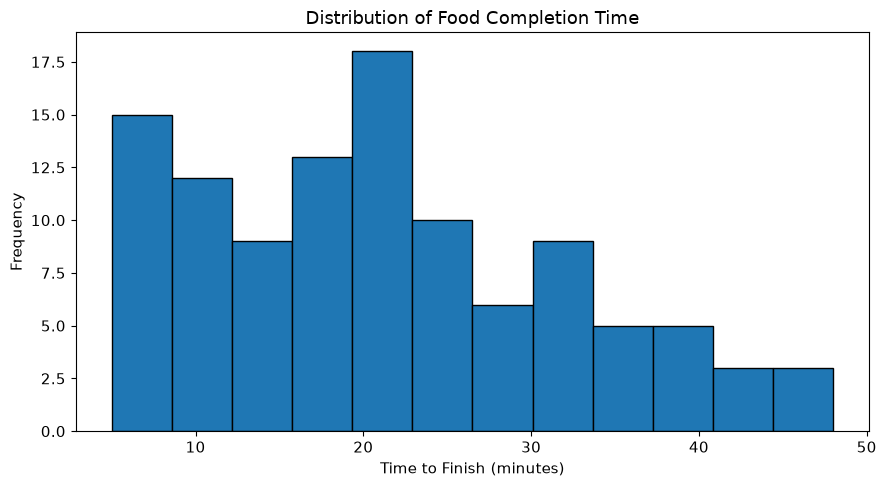

In [11]:
print(df["time_to_finish"].describe())

plt.figure(figsize=(9, 5))
plt.hist(df["time_to_finish"].dropna(), bins=12, edgecolor="black")
plt.xlabel("Time to Finish (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Food Completion Time")
plt.tight_layout()
plt.show()

### Outliers

In [12]:
target = df["time_to_finish"].dropna()
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

outliers = df[(df["time_to_finish"] < lower) | (df["time_to_finish"] > upper)]
outliers[["record_id", "date", "category", "participant_id", "crowd_level", "time_to_finish"]]

Q1: 12.75
Q3: 29.0
IQR: 16.25
Lower bound: -11.625
Upper bound: 53.375


,record_id,date,category,participant_id,crowd_level,time_to_finish


C:\Users\vkman\AppData\Local\Temp\ipykernel_13016\727384335.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["time_to_finish"].dropna(), vert=True)


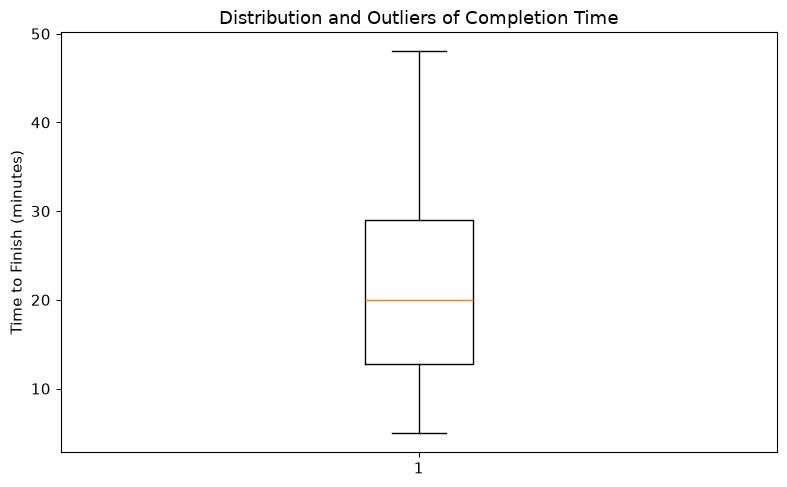

In [13]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["time_to_finish"].dropna(), vert=True)
plt.ylabel("Time to Finish (minutes)")
plt.title("Distribution and Outliers of Completion Time")
plt.tight_layout()
plt.show()

### Completion time by meal category

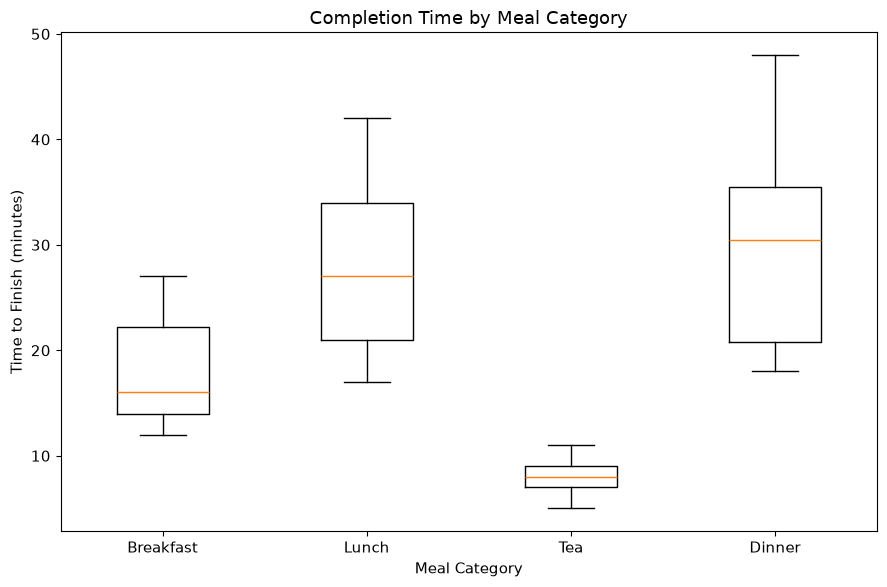

In [14]:
categories = ["Breakfast", "Lunch", "Tea", "Dinner"]
data = [df.loc[df["category"] == c, "time_to_finish"].dropna() for c in categories]

plt.figure(figsize=(9, 6))
plt.boxplot(data, tick_labels=categories)
plt.xlabel("Meal Category")
plt.ylabel("Time to Finish (minutes)")
plt.title("Completion Time by Meal Category")
plt.tight_layout()
plt.show()

category
Breakfast    18.107143
Lunch        28.037037
Tea           8.160000
Dinner       29.535714
Name: time_to_finish, dtype: float64


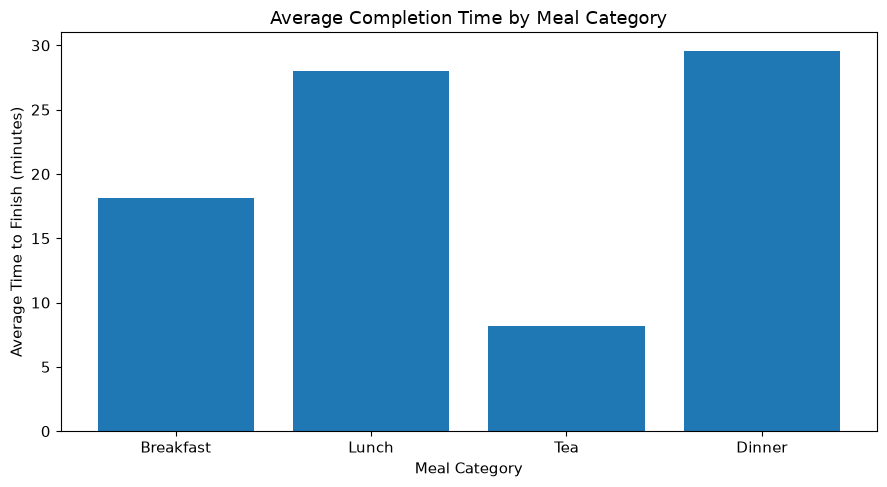

In [15]:
category_mean = df.groupby("category")["time_to_finish"].mean().reindex(categories)
print(category_mean)

plt.figure(figsize=(9, 5))
plt.bar(category_mean.index, category_mean.values)
plt.xlabel("Meal Category")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Average Completion Time by Meal Category")
plt.tight_layout()
plt.show()

### Completion time by crowd level

crowd_level
Low       14.500000
Medium    22.200000
High      33.636364
Name: time_to_finish, dtype: float64


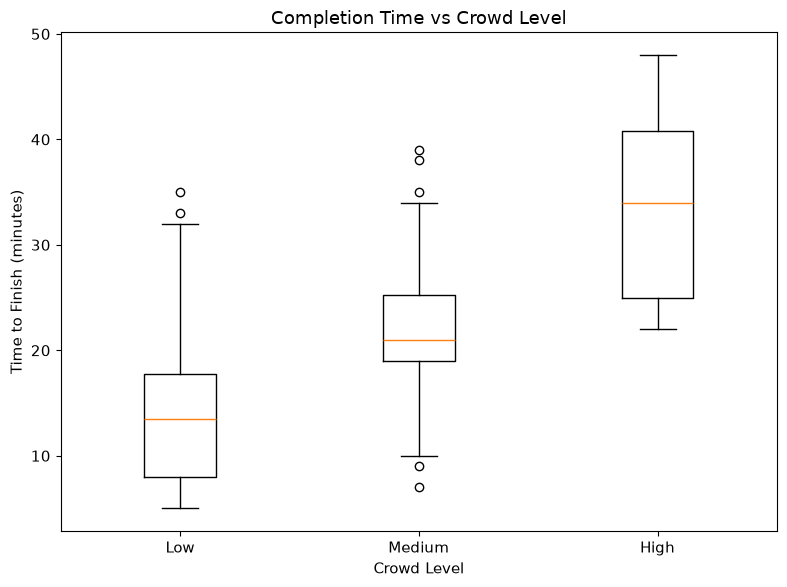

In [16]:
crowd_order = ["Low", "Medium", "High"]
crowd_mean = df.groupby("crowd_level")["time_to_finish"].mean().reindex(crowd_order)
print(crowd_mean)

data = [df.loc[df["crowd_level"] == c, "time_to_finish"].dropna() for c in crowd_order]
plt.figure(figsize=(8, 6))
plt.boxplot(data, tick_labels=crowd_order)
plt.xlabel("Crowd Level")
plt.ylabel("Time to Finish (minutes)")
plt.title("Completion Time vs Crowd Level")
plt.tight_layout()
plt.show()

### Completion time by day type

day_type
Weekday    21.028571
Weekend    21.391304
Holiday    22.066667
Name: time_to_finish, dtype: float64


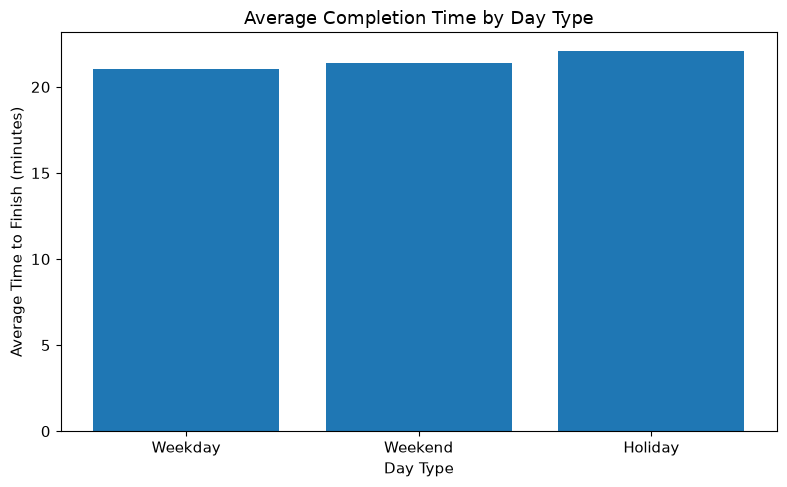

In [17]:
day_type_order = ["Weekday", "Weekend", "Holiday"]
day_type_mean = df.groupby("day_type")["time_to_finish"].mean().reindex(day_type_order)
print(day_type_mean)

plt.figure(figsize=(8, 5))
plt.bar(day_type_mean.index, day_type_mean.values)
plt.xlabel("Day Type")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Average Completion Time by Day Type")
plt.tight_layout()
plt.show()

### Completion time by participant

participant_id
P1    17.211538
P2    25.000000
Name: time_to_finish, dtype: float64


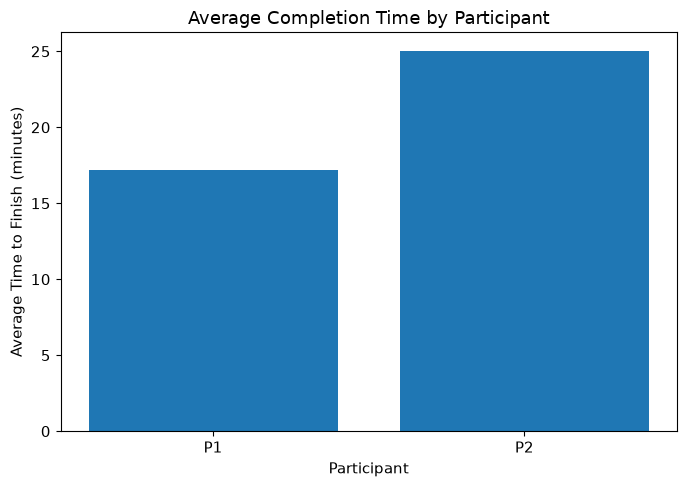

In [18]:
participant_mean = df.groupby("participant_id")["time_to_finish"].mean()
print(participant_mean)

plt.figure(figsize=(7, 5))
plt.bar(participant_mean.index, participant_mean.values)
plt.xlabel("Participant")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Average Completion Time by Participant")
plt.tight_layout()
plt.show()

### Participant and meal category

participant_id         P1         P2
category                            
Breakfast       14.214286  22.000000
Dinner          23.785714  35.285714
Lunch           20.769231  34.785714
Tea              8.454545   7.928571


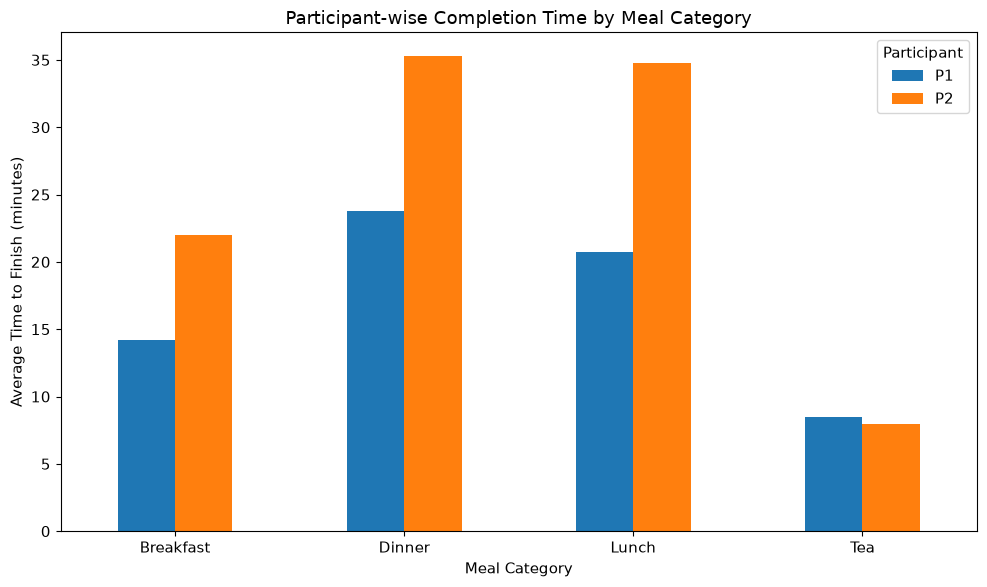

In [19]:
participant_category = (
    df.groupby(["category", "participant_id"])["time_to_finish"]
      .mean()
      .unstack()
)
print(participant_category)

participant_category.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Meal Category")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Participant-wise Completion Time by Meal Category")
plt.xticks(rotation=0)
plt.legend(title="Participant")
plt.tight_layout()
plt.show()

### Completion time across days by meal type

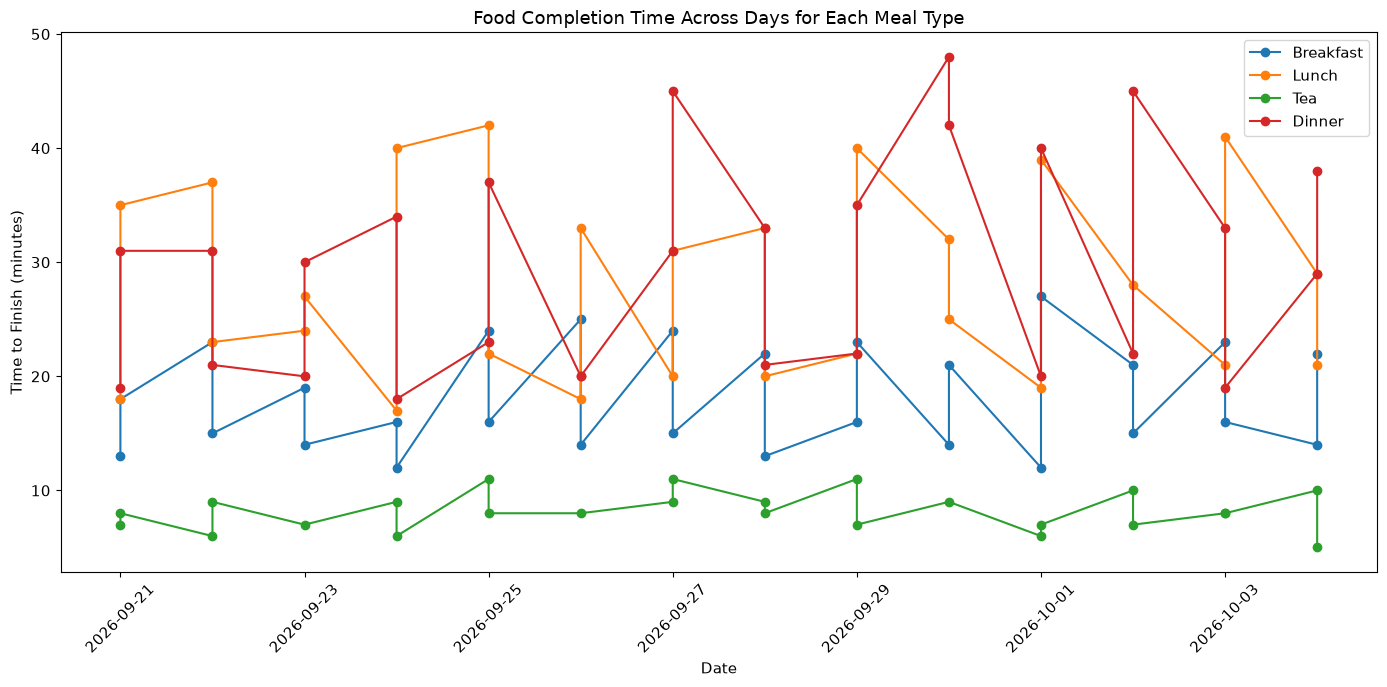

In [20]:
plot_df = df.dropna(subset=["date", "time_to_finish"]).sort_values("date")

plt.figure(figsize=(14, 7))
for category in categories:
    temp = plot_df[plot_df["category"] == category]
    plt.plot(temp["date"], temp["time_to_finish"], marker="o", linewidth=1.5, label=category)

plt.xlabel("Date")
plt.ylabel("Time to Finish (minutes)")
plt.title("Food Completion Time Across Days for Each Meal Type")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

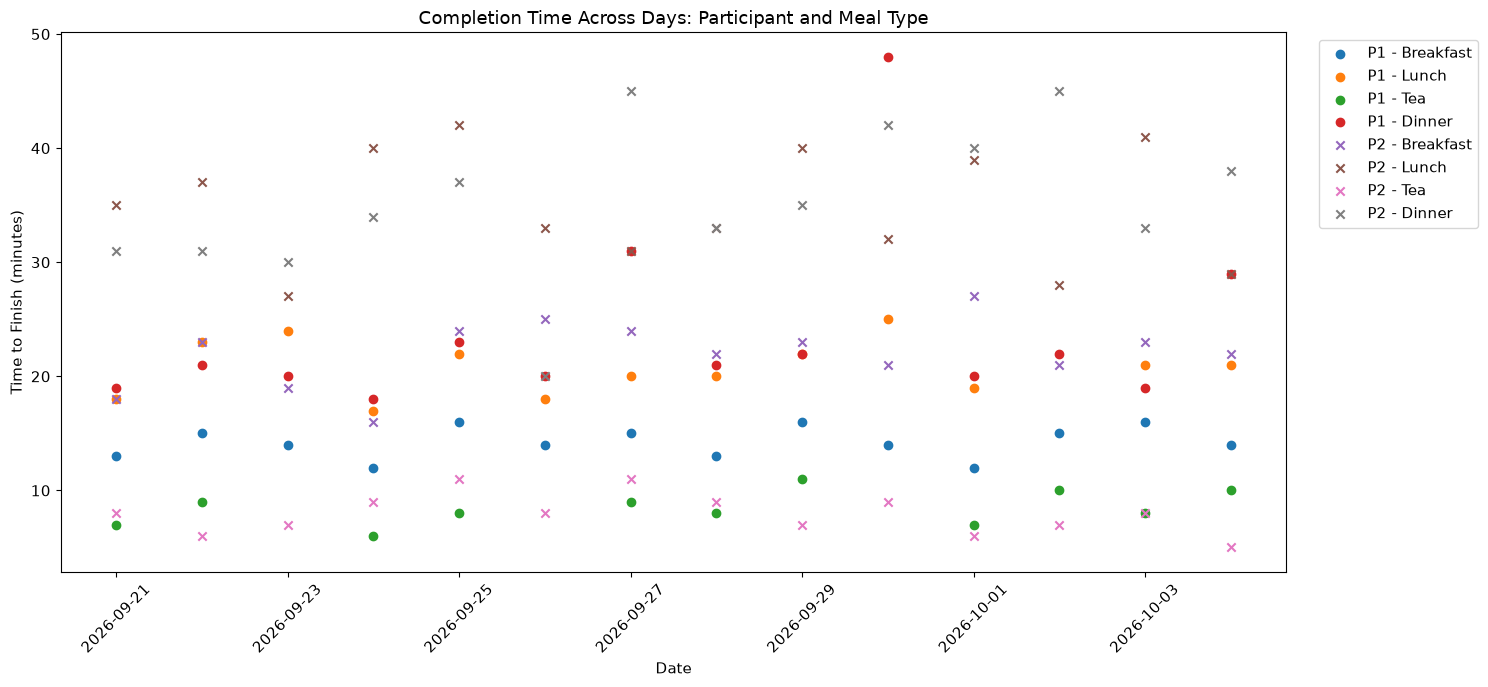

In [21]:
plt.figure(figsize=(15, 7))
markers = {"P1": "o","P2": "x"}
for participant in df["participant_id"].dropna().unique():
    for category in categories:
        temp = df[(df["participant_id"] == participant) & (df["category"] == category)].dropna(subset=["date", "time_to_finish"])
        plt.scatter(temp["date"], temp["time_to_finish"], marker=markers.get(participant, "o"), label=f"{participant} - {category}")
plt.xlabel("Date")
plt.ylabel("Time to Finish (minutes)")
plt.title("Completion Time Across Days: Participant and Meal Type")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Completion time by day of week

day
Monday       19.250000
Tuesday      21.312500
Wednesday    23.714286
Thursday     20.125000
Friday       22.066667
Saturday     20.466667
Sunday       22.125000
Name: time_to_finish, dtype: float64


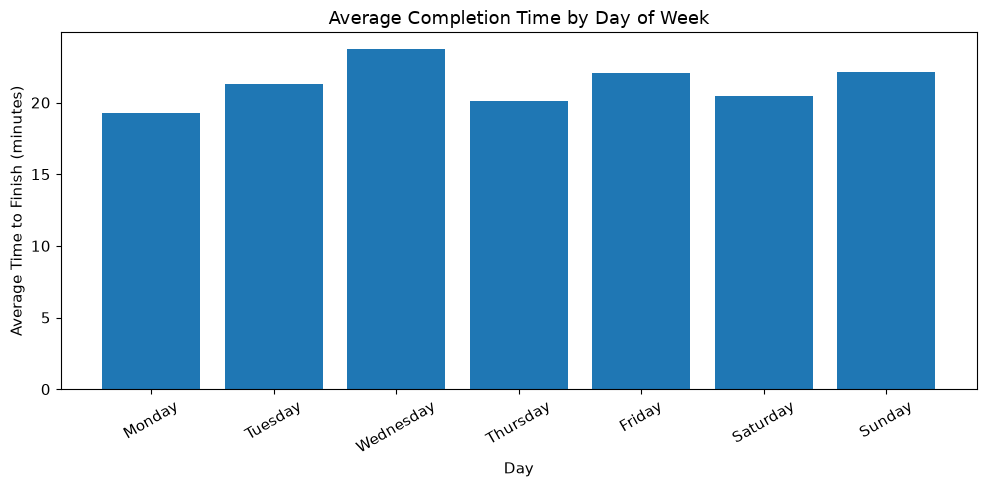

In [22]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_mean = df.groupby("day")["time_to_finish"].mean().reindex(day_order)
print(day_mean)

plt.figure(figsize=(10, 5))
plt.bar(day_mean.index, day_mean.values)
plt.xlabel("Day")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Average Completion Time by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Meal category and day

day        Monday  Tuesday  Wednesday  Thursday     Friday  Saturday  Sunday
category                                                                    
Breakfast    16.5    19.25       17.0     16.75  19.000000     19.50   18.75
Lunch        26.5    30.50       27.0     28.75  30.666667     28.25   25.25
Tea           8.0     8.25        8.0      7.00   9.000000      8.00    8.75
Dinner       26.0    27.25       35.0     28.00  31.750000     23.00   35.75


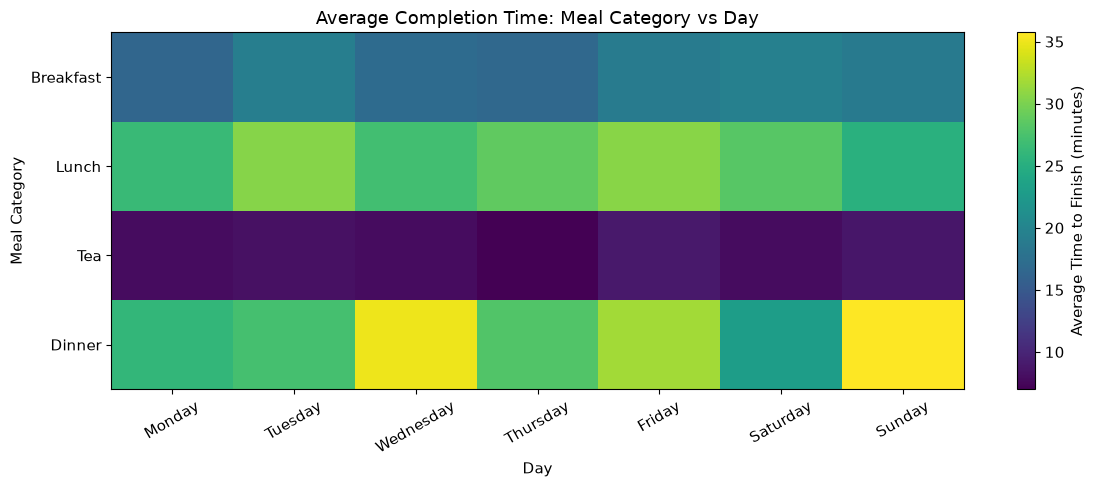

In [23]:
meal_day = (
    df.pivot_table(values="time_to_finish", index="category", columns="day", aggfunc="mean")
      .reindex(index=categories, columns=day_order)
)
print(meal_day)

plt.figure(figsize=(12, 5))
plt.imshow(meal_day, aspect="auto")
plt.colorbar(label="Average Time to Finish (minutes)")
plt.xticks(range(len(meal_day.columns)), meal_day.columns, rotation=30)
plt.yticks(range(len(meal_day.index)), meal_day.index)
plt.xlabel("Day")
plt.ylabel("Meal Category")
plt.title("Average Completion Time: Meal Category vs Day")
plt.tight_layout()
plt.show()

### Relation between waiting time and completion time

                waiting_min  time_to_finish
waiting_min        1.000000        0.660401
time_to_finish     0.660401        1.000000


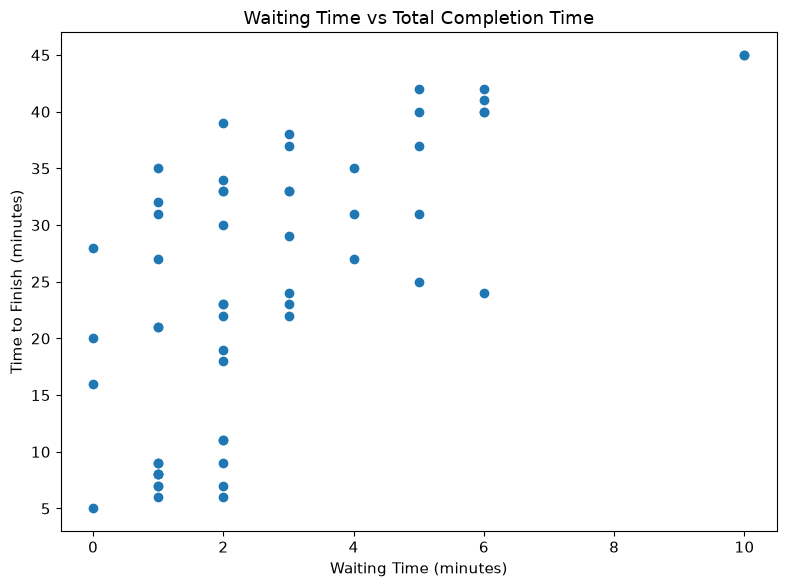

In [24]:
valid_waiting = df.dropna(subset=["waiting_min", "time_to_finish"])
print(valid_waiting[["waiting_min", "time_to_finish"]].corr())

plt.figure(figsize=(8, 6))

plt.scatter(
    valid_waiting["waiting_min"],
    valid_waiting["time_to_finish"]
)

plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Time to Finish (minutes)")
plt.title("Waiting Time vs Total Completion Time")

plt.tight_layout()
plt.show()

### Time of day

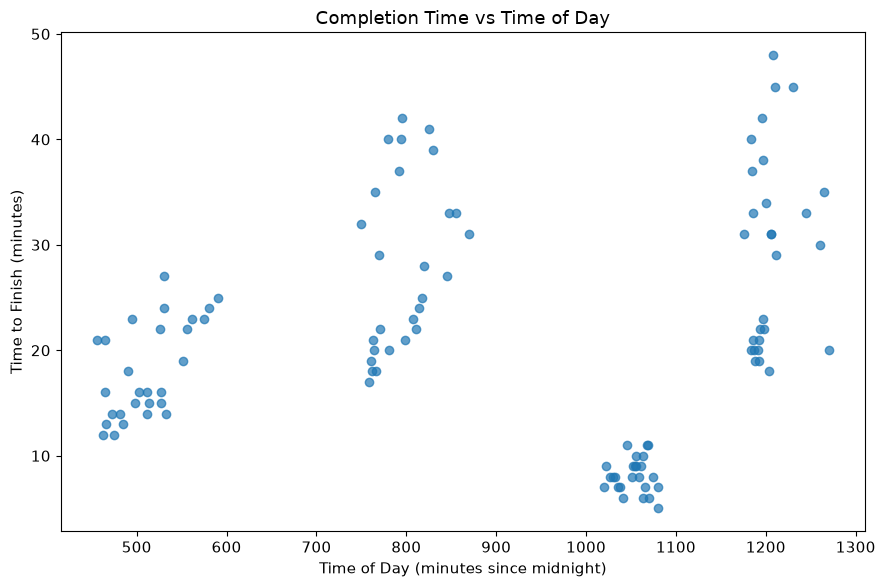

In [25]:
valid_time = df.dropna(subset=["time_minutes", "time_to_finish"])

plt.figure(figsize=(9, 6))
plt.scatter(valid_time["time_minutes"], valid_time["time_to_finish"], alpha=0.7)
plt.xlabel("Time of Day (minutes since midnight)")
plt.ylabel("Time to Finish (minutes)")
plt.title("Completion Time vs Time of Day")
plt.tight_layout()
plt.show()

### Crowd level and completion time

                crowd_numeric  time_to_finish
crowd_numeric        1.000000        0.661569
time_to_finish       0.661569        1.000000


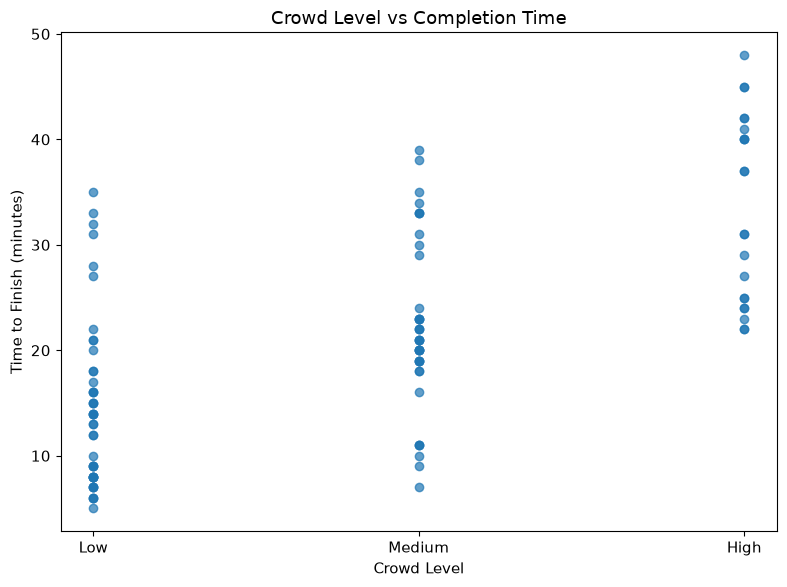

In [26]:
crowd_mapping = {"Low": 1, "Medium": 2, "High": 3}
df["crowd_numeric"] = df["crowd_level"].map(crowd_mapping)

print(df[["crowd_numeric", "time_to_finish"]].corr())

plt.figure(figsize=(8, 6))
plt.scatter(df["crowd_numeric"], df["time_to_finish"], alpha=0.7)
plt.xticks([1, 2, 3], ["Low", "Medium", "High"])
plt.xlabel("Crowd Level")
plt.ylabel("Time to Finish (minutes)")
plt.title("Crowd Level vs Completion Time")
plt.tight_layout()
plt.show()

### Meal category and crowd level

crowd_level       High        Low     Medium
category                                    
Breakfast    25.333333  15.611111  21.428571
Lunch        31.600000  25.500000  26.181818
Tea                NaN   7.631579   9.833333
Dinner       38.666667  29.333333  24.437500


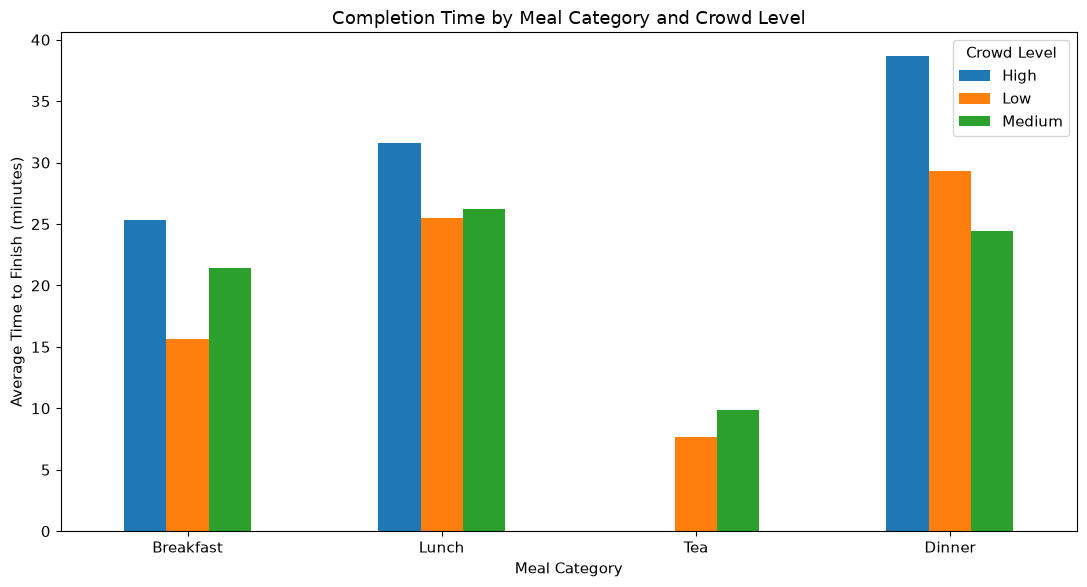

In [27]:
grouped = (
    df.groupby(["category", "crowd_level"])["time_to_finish"]
      .mean()
      .unstack()
      .reindex(categories)
)
print(grouped)

grouped.plot(kind="bar", figsize=(11, 6))
plt.xlabel("Meal Category")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Completion Time by Meal Category and Crowd Level")
plt.xticks(rotation=0)
plt.legend(title="Crowd Level")
plt.tight_layout()
plt.show()

### Waiting time

                waiting_min  time_to_finish
waiting_min        1.000000        0.660401
time_to_finish     0.660401        1.000000


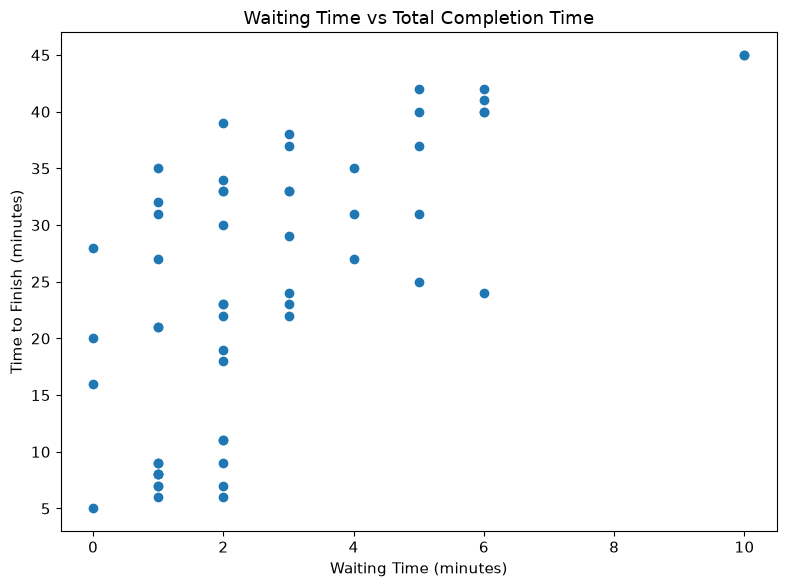

In [28]:
valid_waiting = df.dropna(subset=["waiting_min", "time_to_finish"])
print(valid_waiting[["waiting_min", "time_to_finish"]].corr())

plt.figure(figsize=(8, 6))
plt.scatter(valid_waiting["waiting_min"], valid_waiting["time_to_finish"])
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Time to Finish (minutes)")
plt.title("Waiting Time vs Total Completion Time")
plt.tight_layout()
plt.show()

### Unusual recorded times

In [29]:
time_anomalies = df[(df["time_minutes"] < 6 * 60) | (df["time_minutes"] > 23 * 60)]
time_anomalies[["record_id", "date", "day", "time", "category", "participant_id", "time_to_finish"]]

,record_id,date,day,time,category,participant_id,time_to_finish


### EDA summary by meal

In [30]:
eda_summary = (
    df.groupby("category")["time_to_finish"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)
eda_summary

,count,mean,median,std,min,max
category,,,,,,
Breakfast,28,18.107143,16.0,4.540674,12.0,27.0
Dinner,28,29.535714,30.5,9.255557,18.0,48.0
Lunch,27,28.037037,27.0,8.159381,17.0,42.0
Tea,25,8.160000,8.0,1.650253,5.0,11.0


In [31]:
summary = pd.DataFrame({
    "Mean": df["time_to_finish"].mean(),
    "Median": df["time_to_finish"].median(),
    "Std Dev": df["time_to_finish"].std(),
    "Minimum": df["time_to_finish"].min(),
    "Maximum": df["time_to_finish"].max(),
    "Missing": df["time_to_finish"].isna().sum()
}, index=["Time to Finish"])

summary

,Mean,Median,Std Dev,Minimum,Maximum,Missing
Time to Finish,21.25,20.0,10.761757,5.0,48.0,4
